<a href="https://colab.research.google.com/github/JJulianOlivera/educursos/blob/main/Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# 1. Configuración global para ver las tablas lindas con 2 decimales
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid")

In [13]:
# 2. Carga el nuevo dataset de regresión
df_reg = pd.read_csv('retailboost_customers_regression.csv')

In [14]:
# 3. Inspección inicial visual y técnica
print(" Primeras 5 filas del Dataset ")
display(df_reg.head())

 Primeras 5 filas del Dataset 


,customer_id,age,income,visits_per_month,satisfaction_score,membership_years,monthly_spent
0,1,56,5122.16,8,4,9,2555.68
1,2,69,4032.47,7,5,0,1737.75
2,3,46,1480.63,9,4,13,1031.05
3,4,32,2515.77,7,1,2,730.76
4,5,60,4266.91,12,1,13,1496.51


In [15]:
print("\n Reporte Técnico de la Estructura (Nulos y Tipos) ")
print(df_reg.info())


 Reporte Técnico de la Estructura (Nulos y Tipos) 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    int64  
 1   age                 500 non-null    int64  
 2   income              500 non-null    float64
 3   visits_per_month    500 non-null    int64  
 4   satisfaction_score  500 non-null    int64  
 5   membership_years    500 non-null    int64  
 6   monthly_spent       500 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 27.5 KB
None


In [16]:
print("\n Resumen Estadístico de las Variables ")
display(df_reg.describe())


 Resumen Estadístico de las Variables 


,customer_id,age,income,visits_per_month,satisfaction_score,membership_years,monthly_spent
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,250.50,44.22,2975.26,7.89,3.02,6.72,1185.08
std,144.48,15.04,981.66,2.69,1.42,4.28,469.08
min,1.00,18.00,800.00,1.00,1.00,0.00,50.00
25%,125.75,32.00,2285.75,6.00,2.00,3.00,915.59
50%,250.50,45.00,2977.48,8.00,3.00,7.00,1152.37
75%,375.25,57.00,3628.67,10.00,4.00,10.00,1449.74
max,500.00,69.00,6078.88,16.00,5.00,14.00,4388.77


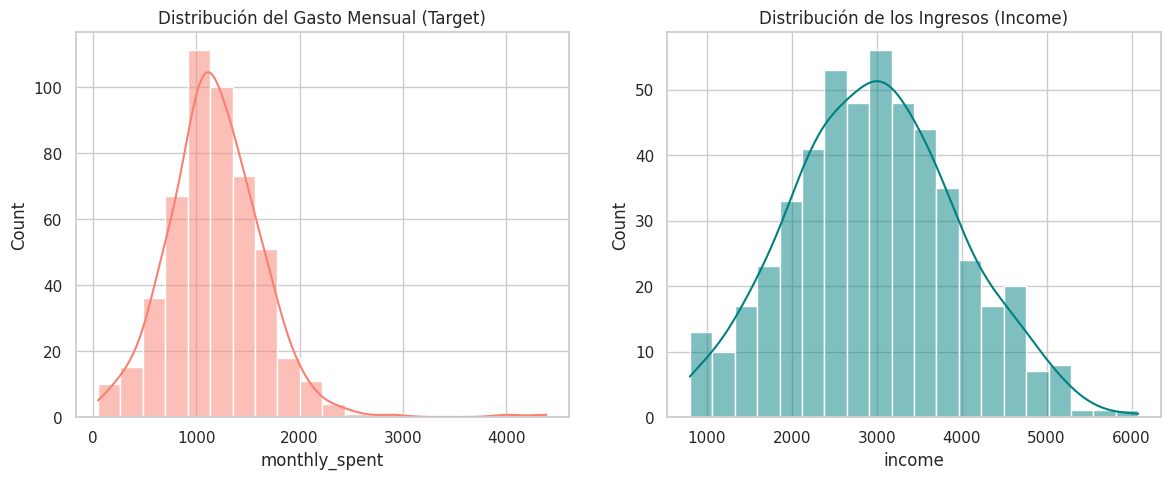

In [17]:
# Creo histogramas usando "bins" (cajas) para entender las montañitas de datos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Nuestra Variable Objetivo (Lo que queremos predecir)
sns.histplot(data=df_reg, x='monthly_spent', bins=20, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribución del Gasto Mensual (Targe)')

# Gráfico 2: El predictor principal tradicional (Ingresos)
sns.histplot(data=df_reg, x='income', bins=20, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribución de los Ingresos (Income)')

plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Separamos nuestras características (X) y el objetivo a predecir (y)
# Borramos el 'customer_id' (no sirve) y el target 'monthly_spent' de las X
X = df_reg.drop(columns=['customer_id', 'monthly_spent'])
y = df_reg['monthly_spent']

# 2. Dividimos en conjunto de Entrenamiento (Train) y Prueba (Test)
# test_size=0.20 significa 20% para el examen. random_state=42 asegura que siempre corte igual.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- MODELO 1: Regresión Lineal Simple ---
# Elegimos una sola variable. En este caso 'income' (ingresos), que vimos que formaba una linda campana.
X_train_simple = X_train[['income']]
X_test_simple = X_test[['income']]

modelo_simple = LinearRegression()
modelo_simple.fit(X_train_simple, y_train) # El modelo simple aprende la relación: Ingreso -> Gasto

# --- MODELO 2: Regresión Lineal Múltiple ---
# Usamos TODAS las variables juntas para que el modelo tenga más contexto (edad, visitas, satisfacción, etc.).
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train) # El modelo múltiple aprende con todo el contexto a la vez

print(" ¡Modelos entrenados con éxito! ")
print(f"Clientes usados para entrenar (Train): {len(X_train)}")
print(f"Clientes guardados para el examen (Test): {len(X_test)}")

 ¡Modelos entrenados con éxito! 
Clientes usados para entrenar (Train): 400
Clientes guardados para el examen (Test): 100


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Hacemos que los modelos "adivinen" (Predicciones)
predicciones_simple = modelo_simple.predict(X_test_simple)
predicciones_multiple = modelo_multiple.predict(X_test)

# 2. Creamos una función rápida para no repetir código al evaluar
def evaluar_modelo(nombre_modelo, y_real, y_predicho):
    mae = mean_absolute_error(y_real, y_predicho)
    rmse = np.sqrt(mean_squared_error(y_real, y_predicho))
    r2 = r2_score(y_real, y_predicho)

    print(f" Resultados de {nombre_modelo} ")
    print(f"MAE  (Error Absoluto Medio): ${mae:.2f}")
    print(f"RMSE (Error Cuadrático)    : ${rmse:.2f}")
    print(f"R²   (Precisión)           : {r2:.4f}\n")

# 3. Mostramos las notas del examen
evaluar_modelo("Regresión Lineal Simple (Solo Ingreso)", y_test, predicciones_simple)
evaluar_modelo("Regresión Lineal Múltiple (Todas las variables)", y_test, predicciones_multiple)

 Resultados de Regresión Lineal Simple (Solo Ingreso) 
MAE  (Error Absoluto Medio): $273.41
RMSE (Error Cuadrático)    : $435.06
R²   (Precisión)           : 0.2236

 Resultados de Regresión Lineal Múltiple (Todas las variables) 
MAE  (Error Absoluto Medio): $240.69
RMSE (Error Cuadrático)    : $401.21
R²   (Precisión)           : 0.3397



In [23]:
# Extraemos los "pesos" o coeficientes que el modelo le asignó a cada variable
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Impacto en el Gasto ($)': modelo_multiple.coef_
}).sort_values(by='Impacto en el Gasto ($)', ascending=False)

print("¿Qué variables hacen que el cliente gaste más?")
display(coeficientes)

¿Qué variables hacen que el cliente gaste más?


,Variable,Impacto en el Gasto ($)
3,satisfaction_score,71.50
4,membership_years,21.94
2,visits_per_month,14.75
1,income,0.26
0,age,0.08


# Informe de Modelado Predictivo (Regresión) - RetailBoost
**Autor:** Julián Olivera | **Rol:** Data Scientist Junior

## 1. Exploración y Preparación de Datos (EDA)
Se analizó un dataset de 500 clientes. La calidad de los datos fue excelente: no se detectaron valores nulos (`NaN`) ni atípicos ilógicos.
* La variable objetivo (`monthly_spent`) tiene una distribución con sesgo a la derecha, con un gasto promedio de **$1185**, pero con presencia de clientes "ballena" que gastan hasta **$4388**.
* La variable predictora `income` (ingresos) presenta una distribución normal perfecta, centrada en los **$3000** mensuales.

## 2. Entrenamiento y Evaluación de Modelos
Se dividió el dataset en 80% para entrenamiento (Train) y 20% para prueba (Test). Se entrenaron dos modelos:
1. **Regresión Lineal Simple:** Utilizando únicamente los ingresos (`income`).
2. **Regresión Lineal Múltiple:** Utilizando todas las variables demográficas y de comportamiento.

**Resultados en el conjunto de Prueba (Test):**
* **Modelo Simple:** R² = 0.2236 | MAE = $273.41
* **Modelo Múltiple:** R² = 0.3397 | MAE = $240.69

**Conclusión del Ajuste:** El Modelo Múltiple es superior. Logra explicar casi el **34%** del comportamiento de gasto del cliente. Su error promedio (MAE de $240) representa una desviación de apenas el **20%** respecto al gasto medio ($1185), lo cual es un margen altamente razonable y aceptable para predecir el comportamiento humano en retail. El RMSE ($401) indica que al modelo le cuesta más predecir con exactitud a los clientes que gastan cifras extremas.

## 3. Insights de Negocio (Interpretación de Coeficientes)
Al analizar los pesos (coeficientes) del Modelo Múltiple, descubrimos los verdaderos motores de venta de RetailBoost:
1. **La Satisfacción es oro:** Por cada punto adicional en el `satisfaction_score`, el cliente gasta **$71.50** adicionales al mes. El equipo de Atención al Cliente es vital para la facturación.
2. **La Lealtad paga:** La antigüedad (`membership_years`) suma **$21.94** extra por cada año cumplido.
3. **Poder Adquisitivo:** El ingreso (`income`) tiene un impacto directo de **$0.26** por cada dólar ganado. Un aumento de $1000 en el salario de un cliente se traduce en $260 extra de gasto en nuestra tienda.
4. **Variable a descartar:** La edad (`age`) demostró tener un impacto nulo en la decisión de compra ($0.08 por año de vida), sugiriendo que nuestro producto atrae a todas las generaciones por igual.